## GMLVQ Module tesnt

In [1]:
import torch
import os
import torch.nn as nn
import numpy as np
from Models.gmlvq import GMLVQ, tensor_split
from sklearn.datasets import load_iris
import pandas as pd
from typing import List
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

data_path = '../breast_cancer_data.csv'

## Data laoding

In [2]:
def extract_cols_by_type(df):
    """Group data by column dtypes"""
    num_cols = []
    cat_cols = []
    for col_name, col_dtype in zip(df.dtypes.index, df.dtypes.values):
        if pd.api.types.is_integer_dtype(col_dtype):
            num_cols.append(col_name)
        elif pd.api.types.is_string_dtype(col_dtype):
            cat_cols.append(col_name)
    return num_cols, cat_cols


def clean_cols(col_names: List):
    """clean col names"""
    return [col_name.replace(' ', '_').lower() for col_name in col_names]

if __name__ == '__main__':
    df = pd.read_csv(data_path)
    num_cols, cat_cols = extract_cols_by_type(df)
    clean_num_cols, clean_cat_cols = clean_cols(num_cols), clean_cols(cat_cols)
    mapping = dict(zip(num_cols + cat_cols, clean_num_cols + clean_cat_cols))
    df = df.rename(columns= mapping)

clean_cat_cols.remove('status')

In [12]:
len(cat_cols), len(num_cols)

(11, 5)

## Building Model Pipeline

In [3]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, clean_num_cols),
    ('cat', cat_pipeline, clean_cat_cols)
])

X = df.loc[:, clean_num_cols + clean_cat_cols]
y = df.loc[:, 'status']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

y_transform = LabelEncoder()

x_clean = preprocessor.fit_transform(x_train)
y_clean = y_transform.fit_transform(y_train)

smote = SMOTE(random_state=0)
x_resampled, y_resampled = smote.fit_resample(x_clean, y_clean)

y_test_c = y_transform.transform(y_test)
x_test_c = preprocessor.transform(x_test)

x_train_t = torch.tensor(x_resampled, dtype=torch.float32)
y_train_t = torch.tensor(y_resampled, dtype=torch.float32)
x_test_t = torch.tensor(x_test_c, dtype=torch.float32)
y_test_t = torch.tensor(y_test_c, dtype=torch.float32)

## GMLVQ Model Fitting

In [4]:
n_classes = len(y_train_t.unique())
in_features = x_train_t.shape[-1]

model = GMLVQ(in_features=in_features, n_classes=n_classes, epochs=11)
model.fit(x_train_t, y_train_t, print_step=1)

Epoch: 1 / 11	|loss: -0.0984
Epoch: 2 / 11	|loss: -0.1242
Epoch: 3 / 11	|loss: -0.1242
Epoch: 4 / 11	|loss: -0.1242
Epoch: 5 / 11	|loss: -0.1243
Epoch: 6 / 11	|loss: -0.1244
Epoch: 7 / 11	|loss: -0.2152
Epoch: 8 / 11	|loss: -0.1511
Epoch: 9 / 11	|loss: -0.1511
Epoch: 10 / 11	|loss: -0.1511
Epoch: 11 / 11	|loss: -0.1511


In [6]:
y_pred = model.predict(x_test_t)
print(classification_report(y_test_t, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       681
         1.0       0.58      0.52      0.55       124

    accuracy                           0.87       805
   macro avg       0.75      0.73      0.74       805
weighted avg       0.86      0.87      0.87       805



In [9]:
svc = SVC(kernel='rbf', random_state=0, C = 0.1)
svc.fit(x_resampled, y_resampled)

y_pred_svc = svc.predict(x_test_c)
print(classification_report(y_test_c, y_pred_svc))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87       681
           1       0.41      0.72      0.52       124

    accuracy                           0.80       805
   macro avg       0.68      0.77      0.70       805
weighted avg       0.86      0.80      0.82       805



## Visualization of feature Relevance

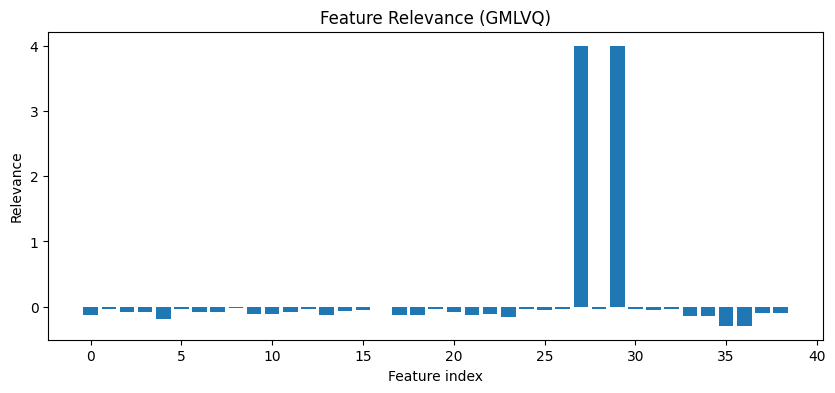

In [10]:
relevance = model.r.detach().numpy()

plt.figure(figsize=(10, 4))
plt.bar(range(len(relevance)), relevance)
plt.title("Feature Relevance (GMLVQ)")
plt.xlabel("Feature index")
plt.ylabel("Relevance")
plt.show()